# Tech Challenge Fase 3 — State of Data Brasil (2023, 2024, 2025-2026)

**Notebook consolidado** com scripts, códigos e etapas utilizadas no projeto, conforme exigido no entregável 3 do enunciado:
> "O grupo deverá entregar os scripts, notebooks e códigos utilizados, de forma organizada e consolidada [...] demonstrando as etapas de ingestão, tratamento, transformação, catalogação, consultas analíticas e geração dos dados utilizados nas análises e gráficos."

Este notebook documenta o pipeline completo: **S3 (raw) → Glue Job PySpark (Bronze + Silver) → Glue Job PySpark (Gold) → Glue Data Catalog → Athena (consultas SQL)**.

A prototipagem inicial da lógica de reconciliação de schema foi validada em pandas (Google Colab) antes de ser portada para PySpark — ambas as implementações estão documentadas aqui, com os mesmos resultados numéricos confirmando a consistência do pipeline.


## 1. Ingestão dos dados

As 3 últimas pesquisas do State of Data Brasil (Data Hackers) foram baixadas do Kaggle e enviadas manualmente para o Amazon S3, no bucket `tech-challenge-658801947656`, região `us-east-1`, organizadas por ano:

```
s3://tech-challenge-658801947656/data-input/raw-2023/
s3://tech-challenge-658801947656/data-input/raw-2024/
s3://tech-challenge-658801947656/data-input/raw-2025-2026/
```

A leitura desses arquivos é feita pelos Glue Jobs em PySpark (seções 2 e 5), usando `spark.read.csv(...)`.

In [ ]:
opcoes_leitura = {"header": True, "multiLine": True, "escape": '"'}
df_2023_raw = spark.read.options(**opcoes_leitura).csv("s3://tech-challenge-658801947656/data-input/raw-2023/")
df_2024_raw = spark.read.options(**opcoes_leitura).csv("s3://tech-challenge-658801947656/data-input/raw-2024/")
df_2025_raw = spark.read.options(**opcoes_leitura).csv("s3://tech-challenge-658801947656/data-input/raw-2025-2026/")


## 2. Tratamento e Transformação — Reconciliação de Schema (Bronze → Silver)

### 2.1 O problema

Os nomes de coluna mudam de formato entre os 3 anos da pesquisa, mesmo para perguntas idênticas:

```
2023:      ('P1_b ', 'Genero')
2024:      1.b_genero
2025-2026: 1.b_genero
```

Além disso, os **códigos** das perguntas (ex: `P4_i`, `4.f`) mudam de ano para ano mesmo quando o texto da pergunta é o mesmo, porque perguntas foram adicionadas/removidas em outros pontos do questionário, deslocando a numeração. Por isso, a reconciliação entre anos é feita pelo **texto normalizado da pergunta**, nunca pelo código ou pela posição da coluna.

### 2.2 Prototipagem em pandas (validação da lógica)

A lógica de parsing e normalização foi primeiro validada em pandas (Google Colab), com os 3 CSVs carregados localmente:

In [ ]:
import pandas as pd
import re
import unicodedata

def parse_coluna_2023(c):
    m = re.match(r"^\('([^']*)',\s*'(.*)'\)$", c, re.DOTALL)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return c, c

def parse_coluna_outros(c):
    codigo, sep, texto = c.partition("_")
    return (codigo, texto) if sep else (c, c)

def normaliza(texto):
    texto = texto.lower().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r"[^a-z0-9]+", " ", texto).strip()
    return texto

# constroi o crosswalk: para cada pergunta normalizada, em quais anos ela aparece
registros = []
for ano, df, parser in [("2023", dataset_2023, parse_coluna_2023),
                          ("2024", dataset_2024, parse_coluna_outros),
                          ("2025-2026", dataset_2025, parse_coluna_outros)]:
    for coluna in df.columns:
        codigo, texto = parser(coluna)
        registros.append({"ano": ano, "coluna_original": coluna, "codigo": codigo,
                           "pergunta_normalizada": normaliza(texto)})

df_todas_colunas = pd.DataFrame(registros)
contagem_anos = df_todas_colunas.groupby("pergunta_normalizada")["ano"].nunique()
perguntas_completas = contagem_anos[contagem_anos == 3]
print(f"Total de colunas processadas: {len(df_todas_colunas)}")
print(f"Perguntas presentes nos 3 anos: {len(perguntas_completas)}")


**Resultado validado:** 1.190 colunas brutas processadas → **215 perguntas** presentes nos 3 anos. Dessas, **43 foram excluídas por ambiguidade** (mesmo texto de opção usado em blocos de pergunta diferentes, ex: "Apache Airflow" aparecendo tanto em "ferramentas que uso" quanto em outro bloco distinto) — restando **172 perguntas seguras** para o merge automático.

Teste de sanidade: a distribuição de `genero` recalculada na base unificada bateu exatamente com o cálculo manual pré-merge (75,1% / 76,1% / 77,5% masculino em 2023/2024/2025-2026), confirmando a integridade da reconciliação.

### 2.3 Implementação em PySpark (Glue Job `silver-state-of-data`)

A mesma lógica foi portada para PySpark e executada como Glue Job, lendo diretamente do S3. Uma limitação específica do Spark exigiu um ajuste: nomes de coluna com parênteses, vírgulas ou pontos (como os do formato de 2023) não podem ser resolvidos como referência de coluna nem gravados em Parquet. A solução foi renomear todas as colunas para nomes posicionais seguros (`c0`, `c1`, `c2`...) logo após a leitura, mantendo a lógica de reconciliação em Python puro sobre a lista de nomes originais (nunca como expressão Spark).

Este mesmo job grava a **camada Bronze** (dado bruto, todas as colunas, sem transformação de negócio, com nomes seguros `c0, c1...`) e a **camada Silver** (schema unificado, 172 perguntas renomeadas para nome de negócio, 3 anos empilhados).

In [ ]:
import sys
import re
import unicodedata
from collections import defaultdict
from functools import reduce

from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from pyspark.sql import functions as F
from awsglue.context import GlueContext
from awsglue.job import Job

args = getResolvedOptions(sys.argv, ['JOB_NAME'])
sc = SparkContext()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)
job.init(args['JOB_NAME'], args)

BUCKET = "s3://tech-challenge-658801947656"
RAW = {
    "2023": f"{BUCKET}/data-input/raw-2023/",
    "2024": f"{BUCKET}/data-input/raw-2024/",
    "2025-2026": f"{BUCKET}/data-input/raw-2025-2026/",
}

def parse_coluna_2023(c):
    m = re.match(r"^\('([^']*)',\s*'(.*)'\)$", c, re.DOTALL)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return c, c

def parse_coluna_outros(c):
    codigo, sep, texto = c.partition("_")
    return (codigo, texto) if sep else (c, c)

def normaliza(texto):
    texto = texto.lower().strip()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r"[^a-z0-9]+", " ", texto).strip()
    return texto

opcoes_leitura = {"header": True, "multiLine": True, "escape": '"'}
df_2023_raw = spark.read.options(**opcoes_leitura).csv(RAW["2023"])
df_2024_raw = spark.read.options(**opcoes_leitura).csv(RAW["2024"])
df_2025_raw = spark.read.options(**opcoes_leitura).csv(RAW["2025-2026"])

dfs_raw = {"2023": df_2023_raw, "2024": df_2024_raw, "2025-2026": df_2025_raw}
parsers = {"2023": parse_coluna_2023, "2024": parse_coluna_outros, "2025-2026": parse_coluna_outros}

# Renomeia colunas para nomes seguros (c0, c1...) - Spark nao consegue resolver
# nomes originais com parenteses/virgulas/pontos como referencia de coluna
dfs = {}
colunas_originais_por_ano = {}
resumo_linhas = []
for ano, df_raw in dfs_raw.items():
    originais = df_raw.columns
    colunas_originais_por_ano[ano] = originais
    nomes_seguros = [f"c{i}" for i in range(len(originais))]
    dfs[ano] = df_raw.toDF(*nomes_seguros)

    # CAMADA BRONZE: dado bruto, todas as colunas, sem transformacao de negocio
    dfs[ano].write.mode("overwrite").parquet(f"{BUCKET}/bronze/{ano}/")
    resumo_linhas.append(f"bronze/{ano}: {dfs[ano].count()} linhas, {len(dfs[ano].columns)} colunas")

# De-para (indice -> nome original) para documentar a Bronze
linhas_mapeamento = []
for ano, originais in colunas_originais_por_ano.items():
    for idx, nome_original in enumerate(originais):
        linhas_mapeamento.append((ano, f"c{idx}", nome_original))
df_mapeamento = spark.createDataFrame(linhas_mapeamento, ["ano_pesquisa", "coluna_bronze", "coluna_original"])
df_mapeamento.write.mode("overwrite").parquet(f"{BUCKET}/bronze/_mapeamento_colunas/")

# Crosswalk (mesma logica validada em pandas, em Python puro sobre indices)
por_pergunta = defaultdict(lambda: defaultdict(list))
for ano, originais in colunas_originais_por_ano.items():
    parser = parsers[ano]
    for idx, coluna in enumerate(originais):
        codigo, texto = parser(coluna)
        pergunta = normaliza(texto)
        por_pergunta[pergunta][ano].append(idx)

perguntas_completas = [p for p, anos in por_pergunta.items() if len(anos) == 3]
perguntas_seguras = [
    p for p in perguntas_completas
    if all(len(por_pergunta[p][ano]) == 1 for ano in ["2023", "2024", "2025-2026"])
]

# CAMADA SILVER: seleciona por indice, renomeia pro nome canonico, empilha os 3 anos
tabelas = []
for ano in ["2023", "2024", "2025-2026"]:
    df = dfs[ano]
    renome_idx = {f"c{por_pergunta[p][ano][0]}": p for p in perguntas_seguras}
    df_sel = df.select([df[c] for c in renome_idx.keys()])
    for original, novo in renome_idx.items():
        df_sel = df_sel.withColumnRenamed(original, novo)
    df_sel = df_sel.withColumn("ano_pesquisa", F.lit(ano))
    tabelas.append(df_sel)

df_silver = reduce(lambda a, b: a.unionByName(b), tabelas)
df_silver.write.mode("overwrite").parquet(f"{BUCKET}/silver/state_of_data_unificado/")

job.commit()


**Resultado validado na AWS (idêntico ao pandas):**
```
bronze/2023: 5293 linhas, 399 colunas
bronze/2024: 5217 linhas, 403 colunas
bronze/2025-2026: 3495 linhas, 388 colunas
bronze/_mapeamento_colunas: 1190 linhas
Perguntas completas (3 anos): 215
Perguntas seguras (sem ambiguidade): 172
Silver final: 14005 linhas, 173 colunas
```


## 3. Catalogação

As tabelas da camada Gold (seção 5) foram catalogadas via **AWS Glue Crawler**, configurado com:

- **Nome:** `gold-state-of-data-crawler`
- **Fonte de dados:** `s3://tech-challenge-658801947656/gold/`
- **IAM Role:** `LabRole`
- **Banco de dados de destino:** `state_of_data_db`
- **Frequência:** On demand

O crawler identificou automaticamente 8 tabelas (uma por subpasta da camada Gold), cada uma catalogada com seu schema (colunas e tipos) inferido a partir dos arquivos Parquet:

```
adocao_ia | cargo_salario | ensino_salario | genero_por_nivel |
modelo_trabalho | regiao_por_nivel | salario_por_nivel | tecnologia
```

Essas tabelas ficaram disponíveis para consulta via SQL no Amazon Athena (seção 4).

## 4. Consultas Analíticas (Amazon Athena)

Consultas SQL executadas diretamente sobre as tabelas catalogadas, via Athena, usando o database `state_of_data_db`.

In [ ]:
-- Query 1: Funil de genero por nivel, com percentual calculado via window function
SELECT
    nivel,
    genero,
    n,
    ROUND(100.0 * n / SUM(n) OVER (PARTITION BY nivel), 1) AS percentual
FROM genero_por_nivel
WHERE nivel IS NOT NULL
ORDER BY
    CASE nivel
        WHEN 'Júnior' THEN 1
        WHEN 'Pleno' THEN 2
        WHEN 'Sênior' THEN 3
        WHEN 'Especialista/Staff+' THEN 4
    END,
    genero;


**Resultado:** proporção de mulheres cai de forma consistente conforme sobe o nível — Júnior 28,2% → Pleno 24,7% → Sênior 21,3% → Especialista 20,1%. Padrão de funil, estável nas 3 edições da pesquisa.

In [ ]:
-- Query 2: Top 5 cargos mais bem pagos (excluindo nulos de skip-logic)
SELECT
    "cargo atual" AS cargo,
    mediana AS salario_mediano,
    n AS respondentes
FROM cargo_salario
WHERE "cargo atual" IS NOT NULL
ORDER BY mediana DESC
LIMIT 5;


**Resultado:** Engenheiro de ML/AI Engineer e Arquiteto de Dados empatados no topo (R$ 14.000 mediana), seguidos por Engenheiro de Dados, Desenvolvedor/Eng. de Software e Professor/Pesquisador (R$ 10.000).

**Nota metodológica:** a primeira execução desta query (sem o filtro `WHERE "cargo atual" IS NOT NULL`) retornou uma linha "fantasma" com cargo em branco e salário de R$ 18.000 — os 3.829 respondentes que pularam o bloco de cargo/nível (skip-logic) foram agrupados pelo `GROUP BY` como se fossem uma categoria de cargo válida. Corrigido filtrando nulos antes do ranking.

In [ ]:
-- Query 3: Evolucao salarial por nivel, ao longo dos 3 anos
SELECT
    ano_pesquisa,
    nivel,
    mediana AS salario_mediano,
    n AS respondentes
FROM salario_por_nivel
WHERE nivel IN ('Júnior', 'Pleno', 'Sênior')
ORDER BY
    CASE nivel WHEN 'Júnior' THEN 1 WHEN 'Pleno' THEN 2 WHEN 'Sênior' THEN 3 END,
    ano_pesquisa;


**Resultado:** Júnior (R$3.500) e Pleno (R$7.000) estagnados nominalmente nos 3 anos; Sênior saltou 40% (R$10.000 → R$14.000) entre 2023 e 2024, mantendo-se em 2025-2026.

In [ ]:
-- Query 4: Adocao de LLM para problemas de negocio, por ano
SELECT * FROM adocao_ia ORDER BY ano_pesquisa;


**Resultado:** 20,1% (2023) → 39,1% (2024) → 52,7% (2025-2026) — mais que dobrou em 3 edições, entre profissionais técnicos que responderam este bloco da pesquisa (~14% da base total por ano).

In [ ]:
-- Query 5: Nivel de ensino x salario mediano
SELECT * FROM ensino_salario ORDER BY mediana DESC;


**Resultado:** progressão clara — Doutorado/Mestrado (R$14.000) > Pós-graduação (R$10.000) > Graduação (R$7.000) > Estudante (R$3.500).

## 5. Geração dos Dados para Análises e Gráficos (Glue Job `gold-state-of-data`)

Script que lê a camada Silver (já validada) e gera 8 tabelas agregadas, uma por pergunta de negócio do enunciado, gravadas em Parquet e posteriormente catalogadas (seção 3) para consulta via Athena (seção 4).

In [ ]:
import sys
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from pyspark.sql import functions as F
from awsglue.context import GlueContext
from awsglue.job import Job

args = getResolvedOptions(sys.argv, ['JOB_NAME'])
sc = SparkContext()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)
job.init(args['JOB_NAME'], args)

BUCKET = "s3://tech-challenge-658801947656"
silver = spark.read.parquet(f"{BUCKET}/silver/state_of_data_unificado/")

# Ponto medio de cada faixa salarial, para permitir agregacoes numericas (mediana/media)
ponto_medio = {
    "Menos de R$ 1.000/mês": 500, "de R$ 1.001/mês a R$ 2.000/mês": 1500,
    "de R$ 2.001/mês a R$ 3.000/mês": 2500, "de R$ 3.001/mês a R$ 4.000/mês": 3500,
    "de R$ 4.001/mês a R$ 6.000/mês": 5000, "de R$ 6.001/mês a R$ 8.000/mês": 7000,
    "de R$ 8.001/mês a R$ 12.000/mês": 10000, "de R$ 12.001/mês a R$ 16.000/mês": 14000,
    "de R$ 16.001/mês a R$ 20.000/mês": 18000, "de R$ 20.001/mês a R$ 25.000/mês": 22500,
    "de R$ 25.001/mês a R$ 30.000/mês": 27500, "de R$ 30.001/mês a R$ 40.000/mês": 35000,
    "Acima de R$ 40.001/mês": 45000,
}
mapa_expr = F.create_map([F.lit(x) for pair in ponto_medio.items() for x in pair])
silver = silver.withColumn("salario_estimado", mapa_expr[F.col("faixa salarial")])

# 1. Genero por nivel
silver.groupBy("nivel", "genero").agg(F.count("*").alias("n")) \
    .write.mode("overwrite").parquet(f"{BUCKET}/gold/genero_por_nivel/")

# 2. Salario por nivel, por ano
silver.groupBy("ano_pesquisa", "nivel").agg(
    F.expr("percentile_approx(salario_estimado, 0.5)").alias("mediana"),
    F.avg("salario_estimado").alias("media"),
    F.count("salario_estimado").alias("n"),
).write.mode("overwrite").parquet(f"{BUCKET}/gold/salario_por_nivel/")

# 3. Adocao de IA (LLM), por ano
col_ia = "utilizo llm s para solucionar problemas de negocio"
silver.groupBy("ano_pesquisa").agg(
    F.sum(F.col(col_ia).cast("double")).alias("usa_llm"),
    F.count(col_ia).alias("respondentes_bloco"),
).withColumn("pct_adocao", F.round(F.col("usa_llm") / F.col("respondentes_bloco") * 100, 1)) \
    .write.mode("overwrite").parquet(f"{BUCKET}/gold/adocao_ia/")

# 4. Tecnologia (linguagens)
colunas_tech = ["python", "r", "sql", "scala", "julia", "rust", "c c c", "sql server"]
linhas_tech = []
for c in colunas_tech:
    agg = silver.agg(F.sum(F.col(c).cast("double")).alias("usa"), F.count(c).alias("respondentes")).collect()[0]
    linhas_tech.append((c, agg["usa"], agg["respondentes"]))
gold_tech = spark.createDataFrame(linhas_tech, ["tecnologia", "usa", "respondentes_bloco"]) \
    .withColumn("pct_adocao", F.round(F.col("usa") / F.col("respondentes_bloco") * 100, 1))
gold_tech.write.mode("overwrite").parquet(f"{BUCKET}/gold/tecnologia/")

# 5. Regiao x senioridade
silver.groupBy("regiao onde mora", "nivel").agg(F.count("*").alias("n")) \
    .write.mode("overwrite").parquet(f"{BUCKET}/gold/regiao_por_nivel/")

# 6. Cargo x salario (minimo 30 respondentes)
silver.groupBy("cargo atual").agg(
    F.expr("percentile_approx(salario_estimado, 0.5)").alias("mediana"),
    F.count("*").alias("n"),
).filter(F.col("n") >= 30).orderBy(F.col("mediana").desc()) \
    .write.mode("overwrite").parquet(f"{BUCKET}/gold/cargo_salario/")

# 7. Nivel de ensino x salario
silver.groupBy("nivel de ensino").agg(
    F.expr("percentile_approx(salario_estimado, 0.5)").alias("mediana"),
    F.count("*").alias("n"),
).orderBy(F.col("mediana").desc()) \
    .write.mode("overwrite").parquet(f"{BUCKET}/gold/ensino_salario/")

# 8. Modelo de trabalho
# Le EXCLUSIVAMENTE da camada Silver (nunca do Raw). A coluna "modelo_trabalho"
# e adicionada no Silver Job com NULL explicito para 2023, ano em que a pergunta
# nao existia no questionario original. Aqui apenas filtramos os nulos antes de
# agregar, preservando a regra de que o Gold nunca acessa a camada Raw.
if "modelo_trabalho" in silver.columns:
    silver.filter(F.col("modelo_trabalho").isNotNull()) \
        .groupBy("ano_pesquisa", "modelo_trabalho").agg(F.count("*").alias("n")) \
        .write.mode("overwrite").parquet(f"{BUCKET}/gold/modelo_trabalho/")

job.commit()


**Resultado validado (pós-correção arquitetural):** 8 tabelas geradas com sucesso, todas lendo exclusivamente da camada Silver — `genero_por_nivel` (20 linhas), `salario_por_nivel` (13), `adocao_ia` (3), `tecnologia` (8), `regiao_por_nivel` (30), `cargo_salario` (18), `ensino_salario` (7), `modelo_trabalho` (8 linhas: 4 categorias × 2 anos, 2023 excluído porque a pergunta não existia naquele ano do questionário).

**Nota de correção:** uma versão anterior deste job lia a coluna de modelo de trabalho diretamente da camada Raw dentro do próprio Gold Job, quebrando a regra de que o Gold só acessa a camada Silver. Isso foi corrigido movendo a extração dessa coluna para o Silver Job (com NULL explícito para 2023), e o Gold Job passou a apenas filtrar e agregar. A correção foi validada com `SELECT DISTINCT` no Athena, confirmando que as 4 categorias de resposta usam o mesmo texto em 2024 e 2025-2026 (sem fragmentação por diferença de string).


## 6. Resumo dos Insights de Negócio

1. **Gênero geral:** representatividade feminina caiu de 24,4% (2023) para 22,0% (2025-2026)
2. **Funil de gênero por senioridade:** mulheres caem de ~28% (Júnior) para ~20% (Especialista), padrão estável nos 3 anos — indica desafio de retenção/promoção, não de atração
3. **Adoção de LLM:** 20,1% → 39,1% → 52,7%, mais que dobrou em 3 anos entre profissionais técnicos
4. **Remuneração por senioridade:** Júnior/Pleno estagnados nominalmente; Sênior saltou 40% (R$10k → R$14k) entre 2023-2024
5. **Tecnologia:** Python e SQL dominantes (>80% de adoção), degrau acentuado para as demais linguagens
6. **Região x senioridade:** Sudeste concentra 60,5% dos respondentes e tem a maior proporção de Sênior — sinal de possível concentração/fuga de talento sênior fora do eixo Sudeste/Sul
7. **Cargo x salário:** cargo mais frequente (Analista de Dados) não é o mais bem pago; papéis especializados (Arquiteto de Dados, ML Engineer) lideram remuneração com volume bem menor
8. **Nível de ensino:** prêmio salarial claro e crescente conforme o nível de formação
9. **Modelo de trabalho:** queda do 100% remoto (45,7% → 39,7%) e alta do 100% presencial (16,3% → 20,8%) entre 2024 e 2025-2026 — sinal de "volta ao escritório" capturado no próprio dado. *(Números recalculados após correção do bug arquitetural na tabela `gold/modelo_trabalho` — ver seção 5.)*


## 7. EDA Inicial (Google Colab, pandas)

Exploração inicial de cada base, antes da reconciliação de schema, para entender volume, tipos de dado e completude.

In [ ]:
import pandas as pd

dataset_2023 = pd.read_csv('/content/State_of_data_BR_2023_Kaggle - df_survey_2023.csv')
dataset_2024 = pd.read_csv('/content/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv')
dataset_2025 = pd.read_csv('/content/Final Dataset - State of Data 2025-2026 - Kaggle.csv')

print("2023:", dataset_2023.shape)
print("2024:", dataset_2024.shape)
print("2025-2026:", dataset_2025.shape)

dataset_2023.info()
dataset_2023.isnull().sum()
dataset_2023.duplicated().sum()
dataset_2023.describe()


**Resultado:** 2023 (5.293 × 399), 2024 (5.217 × 403), 2025-2026 (3.495 × 388). Sem duplicatas exatas de linha. Presença de nulos consistente com lógica condicional de pesquisa (skip-logic), investigada na seção 7.2.

## 8. Código completo de cada Insight (pandas, sobre a Silver unificada)

A partir daqui, todo o código roda sobre `df_silver` (14.005 linhas × 173 colunas), já construída conforme a seção 2.2.

### 8.1 Verificação de Skip-Logic (por que existem nulos em `nivel` e `cargo_atual`)

In [ ]:
# nulos de "nivel" por ano
for ano in ["2023", "2024", "2025-2026"]:
    sub = df_silver[df_silver["ano_pesquisa"] == ano]
    total = len(sub)
    nulos = sub["nivel"].isna().sum()
    print(f"{ano}: {nulos}/{total} nulos ({nulos/total*100:.1f}%)")

# confirma que e o mesmo grupo pulando cargo_atual e nivel juntos (skip-logic, nao bug)
pd.crosstab(df_silver["nivel"].isna(), df_silver["cargo atual"].isna())


**Resultado:** ~27% de nulos em cada ano, proporção consistente entre anos. Correlação perfeita entre nulos de `nivel` e `cargo_atual` (10.176 preenchidos / 3.829 vazios nos dois, zero casos mistos) — confirma que é skip-logic (pessoas fora do mercado de trabalho em dados pulam esse bloco), não erro de mapeamento. **Consequência:** todo cálculo percentual usa como denominador quem respondeu a pergunta, não o total geral.

### 8.2 Gênero geral e Funil de Gênero por Senioridade

In [ ]:
# genero geral por ano
for ano in ["2023", "2024", "2025-2026"]:
    sub = df_silver[df_silver["ano_pesquisa"] == ano]
    print(f"\n{ano} (n={len(sub)}):")
    print((sub["genero"].value_counts(normalize=True) * 100).round(1))

# funil: genero dentro de cada nivel (percentual calculado sobre o total do NIVEL, nao do geral)
cruzamento = pd.crosstab(df_silver["nivel"], df_silver["genero"], normalize="index") * 100
print(cruzamento.round(1))

# mesmo funil, agora por ano tambem, para ver se piora com o tempo
funil_por_ano = df_silver.groupby(["ano_pesquisa", "nivel"])["genero"].value_counts(normalize=True).unstack() * 100
ordem_nivel = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
funil_por_ano = funil_por_ano.reindex(ordem_nivel, level="nivel")
print(funil_por_ano[["Feminino"]].round(1))


### 8.3 Adoção de LLM

In [ ]:
coluna_ia = "utilizo llm s para solucionar problemas de negocio"

for ano in ["2023", "2024", "2025-2026"]:
    sub = df_silver[df_silver["ano_pesquisa"] == ano]
    respondentes = sub[coluna_ia].notna().sum()
    usa_llm = sub[coluna_ia].sum()
    pct = usa_llm / respondentes * 100
    print(f"{ano}: {usa_llm:.0f}/{respondentes} usam LLM ({pct:.1f}%) - base: {respondentes} de {len(sub)} respondentes totais")


### 8.4 Remuneração por Senioridade

In [ ]:
ponto_medio = {
    "Menos de R$ 1.000/mês": 500, "de R$ 1.001/mês a R$ 2.000/mês": 1500,
    "de R$ 2.001/mês a R$ 3.000/mês": 2500, "de R$ 3.001/mês a R$ 4.000/mês": 3500,
    "de R$ 4.001/mês a R$ 6.000/mês": 5000, "de R$ 6.001/mês a R$ 8.000/mês": 7000,
    "de R$ 8.001/mês a R$ 12.000/mês": 10000, "de R$ 12.001/mês a R$ 16.000/mês": 14000,
    "de R$ 16.001/mês a R$ 20.000/mês": 18000, "de R$ 20.001/mês a R$ 25.000/mês": 22500,
    "de R$ 25.001/mês a R$ 30.000/mês": 27500, "de R$ 30.001/mês a R$ 40.000/mês": 35000,
    "Acima de R$ 40.001/mês": 45000,
}
df_silver["salario_estimado"] = df_silver["faixa salarial"].map(ponto_medio)

resumo_salario = df_silver.groupby("nivel")["salario_estimado"].agg(mediana="median", media="mean", n="count") \
    .reindex(["Júnior", "Pleno", "Sênior", "Especialista/Staff+"])
print(resumo_salario.round(0))

resumo_por_ano = df_silver.groupby(["ano_pesquisa", "nivel"])["salario_estimado"].median().unstack() \
    .reindex(columns=["Júnior", "Pleno", "Sênior", "Especialista/Staff+"])
print(resumo_por_ano.round(0))


### 8.5 Cargos: frequência e salário

In [ ]:
top_cargos = df_silver["cargo atual"].value_counts().head(10)
print(top_cargos)

salario_por_cargo = df_silver.groupby("cargo atual")["salario_estimado"].agg(mediana="median", n="count") \
    .query("n >= 30").sort_values("mediana", ascending=False).head(10)
print(salario_por_cargo)


### 8.6 Nível de Ensino

In [ ]:
print(df_silver["nivel de ensino"].value_counts(dropna=False, normalize=True).mul(100).round(1))

salario_por_ensino = df_silver.groupby("nivel de ensino")["salario_estimado"].median().sort_values(ascending=False)
print(salario_por_ensino.round(0))


### 8.7 Tecnologia e Região

In [ ]:
colunas_tech = ["python", "r", "sql", "scala", "julia", "rust", "c c c", "sql server"]
adocao_tech = {}
for c in colunas_tech:
    respondentes = df_silver[c].notna().sum()
    usa = df_silver[c].sum()
    adocao_tech[c] = round(usa / respondentes * 100, 1)
print(pd.Series(adocao_tech).sort_values(ascending=False))

print(df_silver["regiao onde mora"].value_counts(dropna=False, normalize=True).mul(100).round(1))
print(pd.crosstab(df_silver["regiao onde mora"], df_silver["nivel"], normalize="index").mul(100).round(1))


### 8.8 Modelo de Trabalho (2024 e 2025-2026 — pergunta não existe em 2023)

In [ ]:
print(dataset_2024["2.r_modelo_de_trabalho_atual"].value_counts(dropna=False, normalize=True).mul(100).round(1))
print(dataset_2025["2.q_modelo_de_trabalho_atual"].value_counts(dropna=False, normalize=True).mul(100).round(1))


## 9. Evidências Visuais (AWS Console)

Prints de tela documentando a execução real na AWS, complementares ao código:

- Console S3: estrutura de pastas `data-input/`, `bronze/`, `silver/`, `gold/`
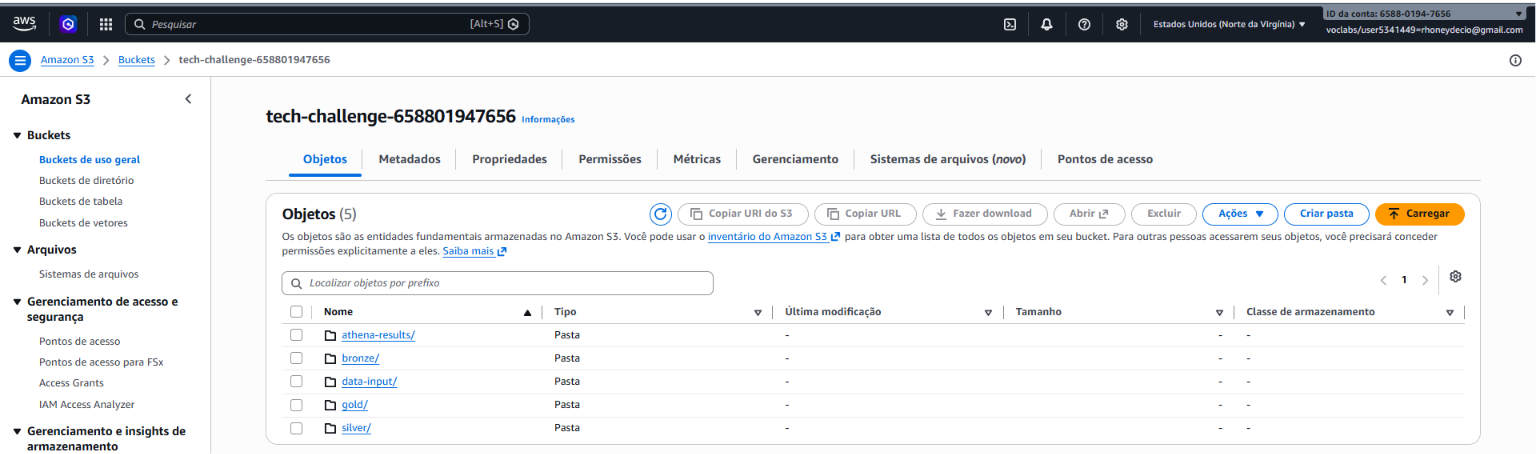

- Console Glue Jobs: execuções bem-sucedidas dos jobs `silver-state-of-data` e `gold-state-of-data`
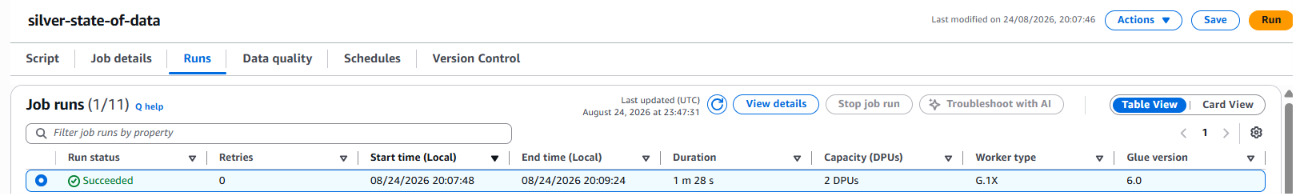

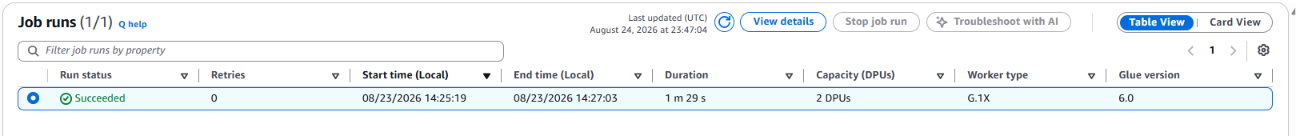

- Console Glue Crawler: 8 tabelas catalogadas em `state_of_data_db`
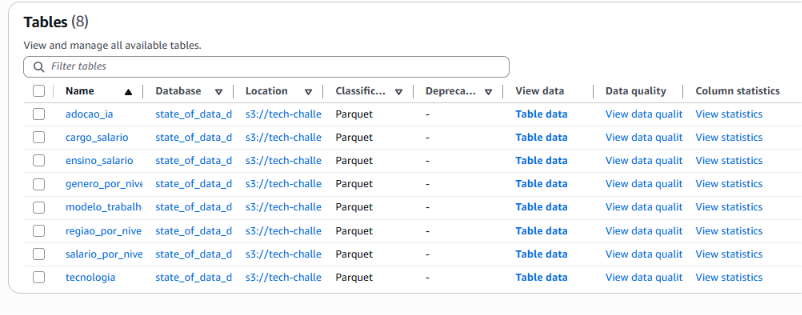

- Console Athena: resultado de uma query executada
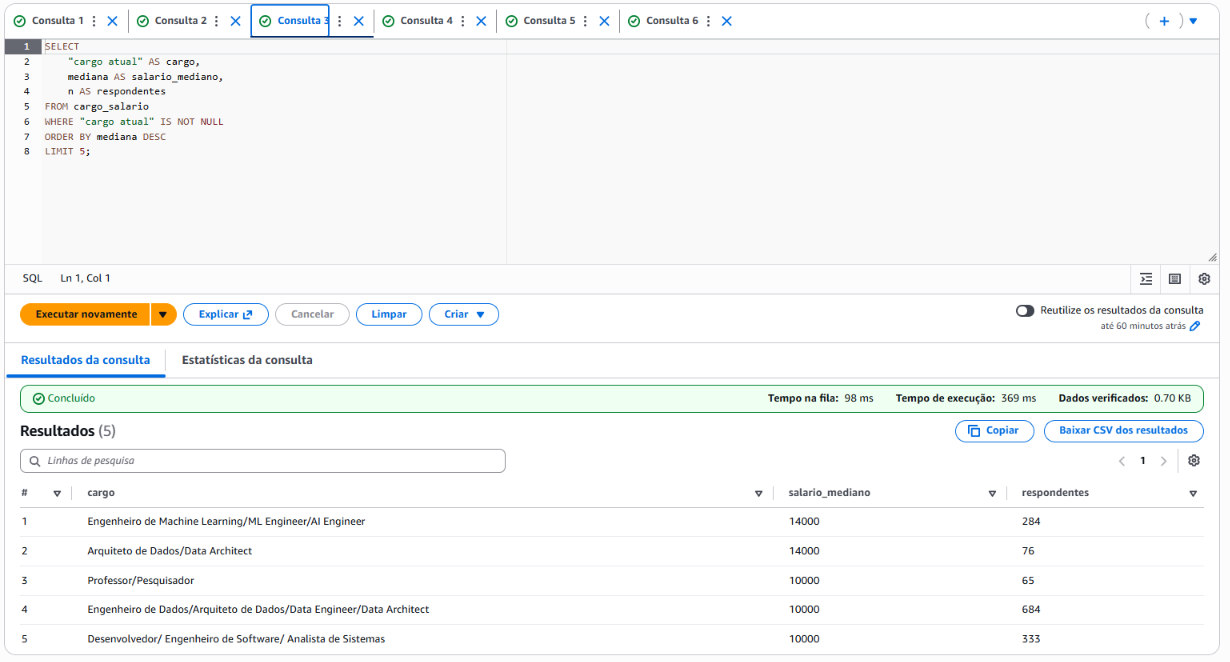